<a href="https://colab.research.google.com/github/Disha092006/Breast-Cancer-Wisconsin-Dataset-/blob/main/Disha_ML_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data?select=data.csv")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dishaverma19
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data


100%|██████████| 48.6k/48.6k [00:00<00:00, 49.1MB/s]

##**Section 1: Data Loading &amp; Exploratory Data Analysis**


Q1. Load the Wisconsin Breast Cancer dataset using pandas and display the first 5 rows.
What is the shape of the dataset? Check the column names and data types.

In [ ]:
import pandas as pd
#load the dataset
df=pd.read_csv("/content/breast-cancer-wisconsin-data/data.csv")
#display first 5 rows
print("First 5 rows:")
print(df.head())
#shape odf the dataset
print("Shape of the Dataset:")
print(df.shape)
#column names
print("Column Names:")
print(df.columns)
#data types
print("Data Types:")
print(df.dtypes)

First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_wor

Q2. Check the target variable diagnosis distribution:
 Count of Malignant (M) vs Benign (B) cases
 Percentage of each class
 Is the dataset balanced or imbalanced? Use value_counts() and plot() to visualize.

Count of each class:
diagnosis
B    357
M    212
Name: count, dtype: int64
Percentage of each class:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


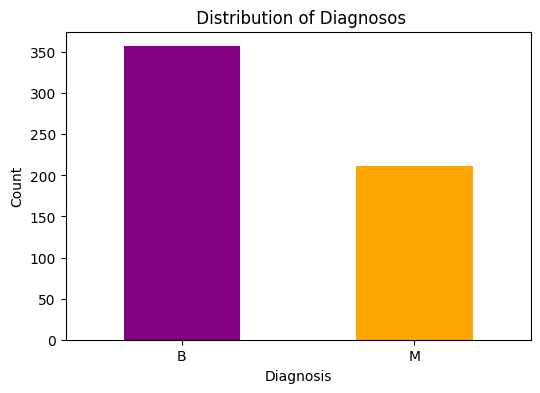

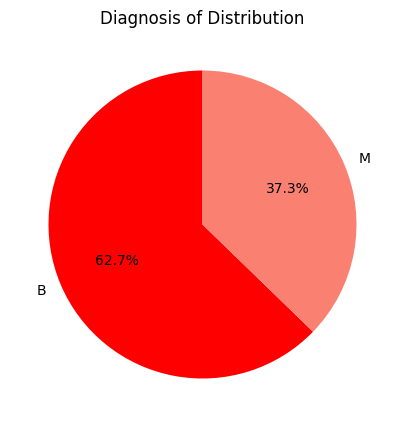

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#load dataset
df=pd.read_csv("/content/breast-cancer-wisconsin-data/data.csv")
#count of each class
print("Count of each class:")
print(df["diagnosis"].value_counts())
#percentage of each class
print("Percentage of each class:")
print(df["diagnosis"].value_counts(normalize=True)*100)
#visualization(bar chart)
plt.figure(figsize=(6,4))
df["diagnosis"].value_counts().plot(kind="bar",color=["purple","orange"])
plt.title(" Distribution of Diagnosos")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()
#pie chart
plt.figure(figsize=(5,5))
df["diagnosis"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["red","salmon"],
    startangle=90)
plt.ylabel("")
plt.title("Diagnosis of Distribution")
plt.show()
#Is the dataset balanced or imbalanced?
#The dataset is slightly imbalanced because the number of Benign (357) cases is greater than the number of Malignant (212) cases. However, the imbalance is not severe, so it is generally suitable for building machine learning classification models without requiring extensive balancing techniques.

Q3. Calculate descriptive statistics for all 30 numerical features using describe(). Identify:
 Which feature has the highest mean value?
 Which feature has the highest standard deviation?
 Are there any features with very low variance (close to 0)?

In [ ]:
import pandas as pd
#load the dataset
df=pd.read_csv("/content/breast-cancer-wisconsin-data/data.csv")
#remove non feature columns
numerical_features=df.drop(columns=["id","diagnosis"])
#descriptive Statistics
print("Descriptive Statistics:")
print(numerical_features.describe())
#feature with highest mean
highest_mean=numerical_features.mean().idxmax()
highest_mean_value=numerical_features.mean().max()
print("Feature with Highest Mean:")
print(highest_mean,":",highest_mean_value)
#feature with highest standard deviation
highest_std=numerical_features.std().idxmax()
highest_std_value=numerical_features.std().max()
print("Feature with Highest Standard Deviation:")
print(highest_std,":",highest_std_value)
#feature with very low variance
variance=numerical_features.var()
low_variance=variance[variance<0.01]
print("Features with Very Low Variance:")
print(low_variance)

Descriptive Statistics:
       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000          

Q4. Create a correlation heatmap for all features using seaborn. Identify:
 Which 3 features have the highest correlation with diagnosis?
 Which features are highly correlated with each other (correlation &gt; 0.8)? Suggest
potential feature removal.

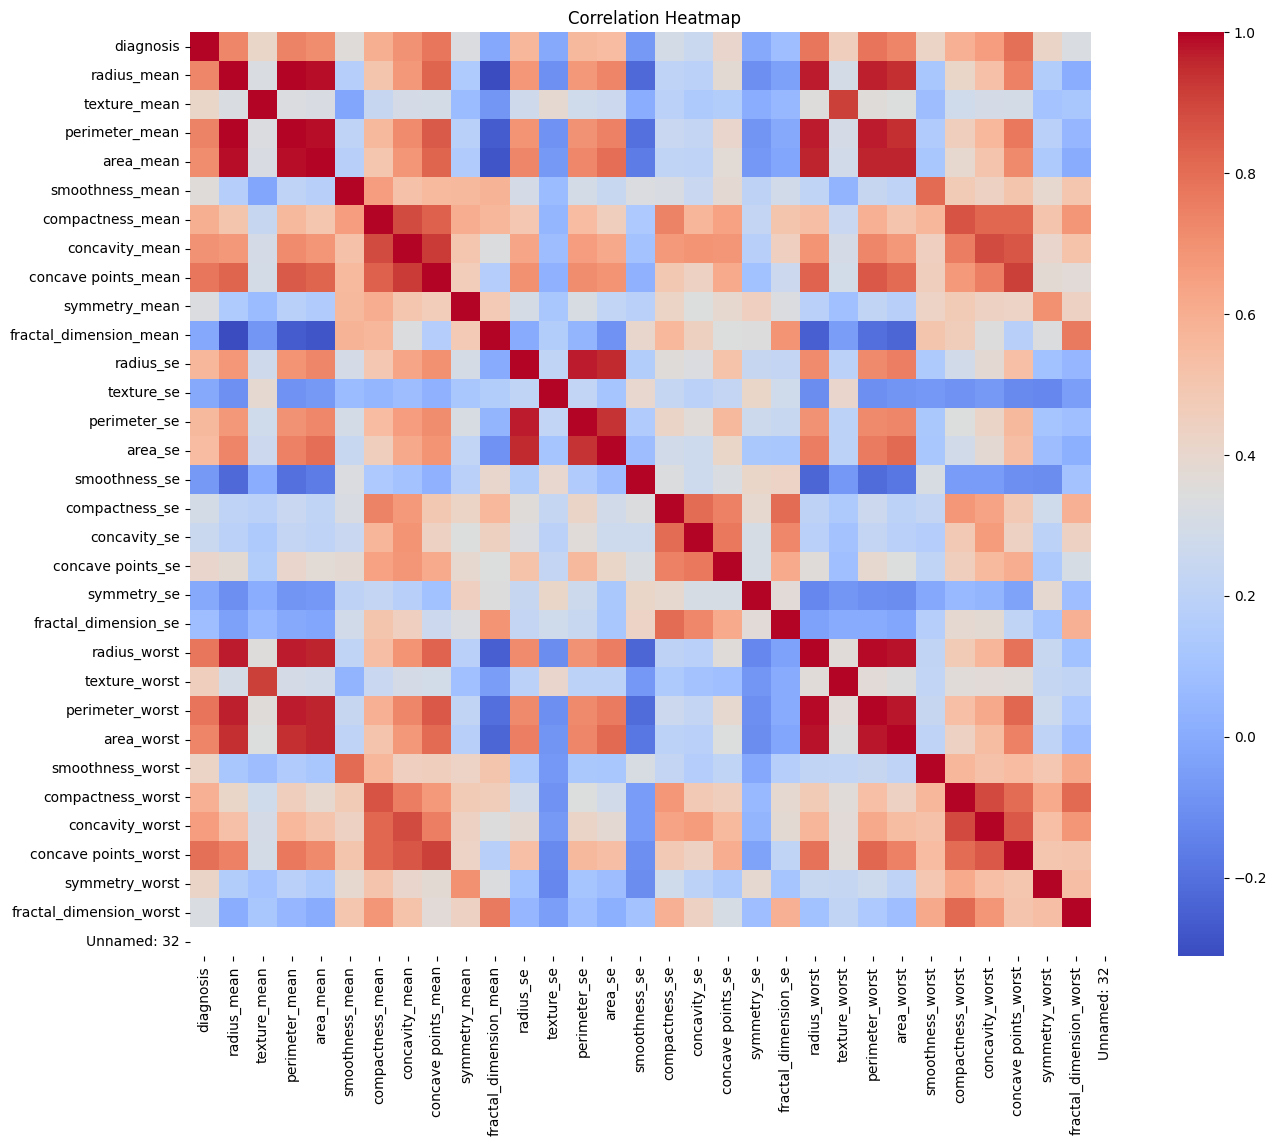

Top 3 features correlated with diagnosis:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
Name: diagnosis, dtype: float64
Highly correlated feature pairs(Correlation>0.8):
perimeter_mean <-> radius_mean = 1.0
area_mean <-> radius_mean = 0.99
area_mean <-> perimeter_mean = 0.99
concavity_mean <-> compactness_mean = 0.88
concave points_mean <-> radius_mean = 0.82
concave points_mean <-> perimeter_mean = 0.85
concave points_mean <-> area_mean = 0.82
concave points_mean <-> compactness_mean = 0.83
concave points_mean <-> concavity_mean = 0.92
perimeter_se <-> radius_se = 0.97
area_se <-> area_mean = 0.8
area_se <-> radius_se = 0.95
area_se <-> perimeter_se = 0.94
concavity_se <-> compactness_se = 0.8
fractal_dimension_se <-> compactness_se = 0.8
radius_worst <-> radius_mean = 0.97
radius_worst <-> perimeter_mean = 0.97
radius_worst <-> area_mean = 0.96
radius_worst <-> concave points_mean = 0.83
texture_worst <-> texture_mean = 0.91
perime

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#load dataset
df=pd.read_csv("/content/breast-cancer-wisconsin-data/data.csv")
#drop unnecessary columns
df.drop(columns=["id"],inplace=True)
#convert diagnosis to numeric
df["diagnosis"]=df["diagnosis"].map({"M":1,"B":0})
#correlation matrix
corr=df.corr()
#heatmap
plt.figure(figsize=(15,12))
sns.heatmap(corr,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
#top 3 features correlated with diagnosis
print("Top 3 features correlated with diagnosis:")
print(corr["diagnosis"].drop("diagnosis").abs().sort_values(ascending=False).head(3))
#highly correlated feature pairs(>0.8)
print("Highly correlated feature pairs(Correlation>0.8):")
for i in range(len(corr.columns)):
  for j in range(i):
    if abs(corr.iloc[i,j])>0.8:
      print(corr.columns[i],"<->",corr.columns[j],"=",round(corr.iloc[i,j],2))
# Suggest potential feature removal.
#Since these pairs are highly correlated (correlation > 0.8), one feature from each pair can be removed to reduce redundancy. For example, you can remove perimeter_mean, perimeter_worst, or area_mean while keeping the corresponding radius features.

Q5. Create box plots for the top 5 features most correlated with diagnosis (radius_mean,
perimeter_mean, area_mean, texture_mean, compactness_mean). What patterns do you
observe between Malignant and Benign cases?

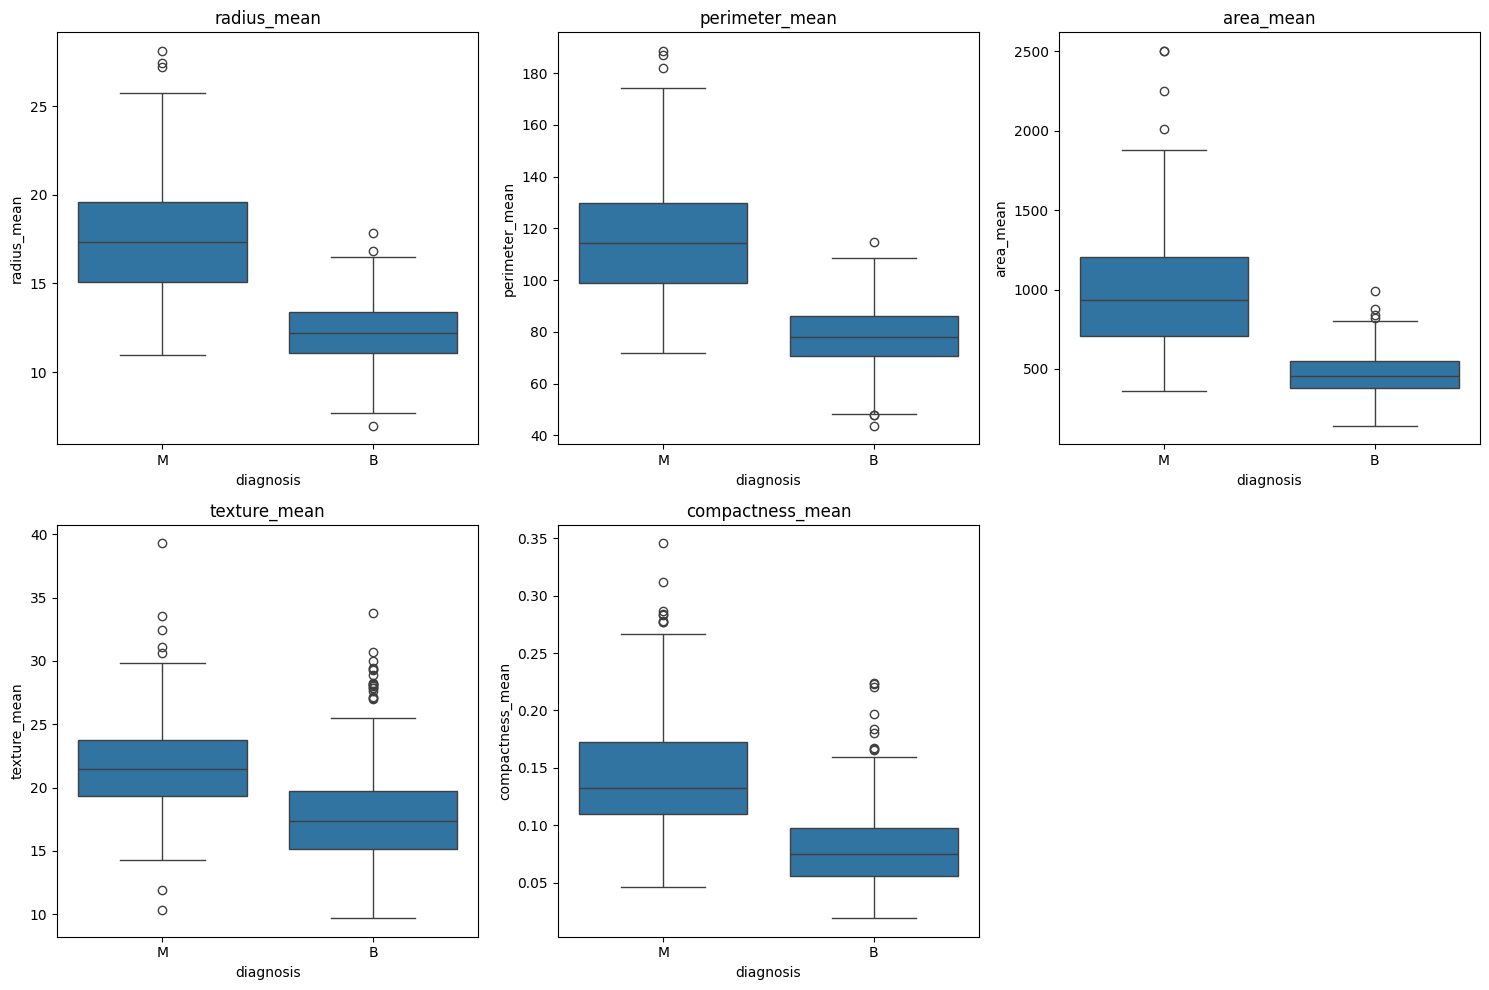

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#load dataset
df=pd.read_csv("/content/breast-cancer-wisconsin-data/data.csv")
#drop unnecessary columns
df.drop(columns=["id"],inplace=True)
#top 5 features
features=["radius_mean","perimeter_mean","area_mean","texture_mean","compactness_mean"]
#cretae box plot
plt.figure(figsize=(15,10))
for i ,feature in enumerate(features):
  plt.subplot(2,3,i+1)
  sns.boxplot(x="diagnosis",y=feature,data=df)
  plt.title(feature)
plt.tight_layout()
plt.show()
#patterns observed between Malignant and Benign cases
#Malignant (M) tumors generally have higher values than Benign (B) tumors for all five features.
#Radius, Perimeter, and Area show a clear separation between Malignant and Benign cases.
#Texture Mean also tends to be higher for Malignant tumors, but there is some overlap.
#Compactness Mean is generally higher for Malignant tumors, indicating denser and more irregular tissue.
#Some outliers are present in both classes, but the overall trend clearly distinguishes Malignant from Benign tumors.
#The features radius_mean, perimeter_mean, area_mean, texture_mean, and compactness_mean are useful for distinguishing between Malignant (M) and Benign (B) breast tumors because Malignant cases generally have larger and higher feature values than Benign cases.

##**Section 2: Data Preprocessing**

Q6. Convert the target variable diagnosis from categorical to numerical:
 Malignant (M) = 1
 Benign (B) = 0
Use map() or replace() and verify the transformation.

In [ ]:
import pandas as pd
#load dataset
df=pd.read_csv("/content/breast-cancer-wisconsin-data/data.csv")
#convert diagnosis:m=1,b=0
df["diagnosis"]=df["diagnosis"].map({"M":1,"B":0})
#verify the transformation
print(df["diagnosis"].head())
print("Unique Values:")
print(df["diagnosis"].unique())
print("Value Counts:")
print(df["diagnosis"].value_counts())
#The transformation is verified using head(), unique(), and value_counts(), confirming that the target variable is now numerical and ready for machine learning models.

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64
Unique Values:
[1 0]
Value Counts:
diagnosis
0    357
1    212
Name: count, dtype: int64


Q7. Check for missing values in the dataset using isnull().sum(). If any missing values
exist, handle them appropriately (drop rows or fill with mean/median).

In [ ]:
import pandas as pd
#load dataset
df=pd.read_csv("/content/breast-cancer-wisconsin-data/data.csv")
#check missing values
print(df.isnull().sum())
#if there are missing values,remove rows containing them
df=df.dropna()
#verify that no missing values remain
print("Missing Values after Handling:")
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

Q8. Split the dataset into features (X) and target (y). Then apply Train-Test split:
 80% training, 20% testing
 Stratify by target variable (to maintain class distribution)
 Use random_state = 42
Display the shape of X_train, X_test, y_train, y_test.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
#load dataset
df=pd.read_csv("/content/breast-cancer-wisconsin-data/data.csv")
#convert diagnosis to numeric
df["diagnosis"]=df["diagnosis"].map({"M":1,"B":0})
#feature(x)and target(y)
x=df.drop("diagnosis",axis=1)
y=df["diagnosis"]
#train-test split(80%train,20%test)
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.20,stratify=y,random_state=42
)
#display shapes
print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
print("y-train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

x_train shape: (455, 32)
x_test shape: (114, 32)
y-train shape: (455,)
y_test shape: (114,)


Q9. Apply Standardization on features using StandardScaler:
 Scale only the training data (fit_transform)
 Transform test data using training scaler (transform)
Why is standardization important for SVM? Display the first 5 rows of scaled training
data.

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
#create standard scaler object
scaler=StandardScaler()
#fit and transform training data
#fit_transform() applied only on the training data.
x_train_scaled=scaler.fit_transform(x_train)
#transform test data
#transform() applied on the test data using the same scaler.
x_test_scaled=scaler.transform(x_test)
#convert scaled training data to dataframe
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
#Display first 5 rows
print("First 5 rows of scaled training data:")
print(x_train_scaled.head())
#Why is Standardization Important for SVM?
#SVM is distance-based, so features with larger values can dominate the model.
#Standardization scales all features to a similar range (mean = 0 and standard deviation = 1).
#It improves model accuracy, training speed, and helps SVM find the optimal decision boundary.

First 5 rows of scaled training data:
         id  radius_mean  texture_mean  perimeter_mean  area_mean  \
0 -0.243221     0.518559      0.891826        0.424632   0.383925   
1  0.408373    -0.516364     -1.639710       -0.541349  -0.542961   
2 -0.242771    -0.368118      0.455515       -0.388250  -0.402970   
3 -0.242751     0.205285      0.726168        0.400330   0.070612   
4 -0.243167     1.243005      0.194195        1.210377   1.206652   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0        -0.974744         -0.689772       -0.688586            -0.398175   
1         0.476219         -0.631834       -0.604281            -0.303075   
2        -1.432979         -0.383927       -0.342175            -0.765459   
3         0.243253          2.203585        2.256094             1.213233   
4        -0.111442          0.051348        0.732962             0.713767   

   symmetry_mean  ...  texture_worst  perimeter_worst  area_worst  \
0      -1.03915

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


##**Section 3: SVM (Support Vector Machine)**

Q10. Implement SVM with Linear Kernel:
 Use SVC(kernel=&#39;linear&#39;, random_state=42)
 Train on scaled training data
 Predict on test data
 Calculate Accuracy, Precision, Recall, F1-Score, and ROC-AUC
 Display the confusion matrix

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score
from sklearn.metrics import f1_score,roc_auc_score,confusion_matrix
import pandas as pd

#Create linear SVM model
svm_linear=SVC(kernel="linear",random_state=42)

# The x_train_scaled and x_test_scaled dataframes contain 'id' (identifier)
# and 'Unnamed: 32' (all NaNs) columns. SVC cannot handle NaN values,
# and 'id' is not a feature for prediction.
# Drop these columns before training the model.
columns_to_drop = ['id', 'Unnamed: 32']

# Ensure x_test_scaled is a DataFrame before calling .drop()
x_test_scaled_df = pd.DataFrame(x_test_scaled, columns=x_test.columns)

x_train_cleaned = x_train_scaled.drop(columns=columns_to_drop, errors='ignore')
x_test_cleaned = x_test_scaled_df.drop(columns=columns_to_drop, errors='ignore')

#train the model
svm_linear.fit(x_train_cleaned,y_train)
#predict on test data
y_pred=svm_linear.predict(x_test_cleaned)
#calculate  evaluation metrics
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1-Score:",f1_score(y_test,y_pred))
print("ROC-AUC:",roc_auc_score(y_test,y_pred))
#display confusion matrix
#Confusion Matrix: Displays the number of correctly and incorrectly classified Benign and Malignant cases. A high number of correct predictions indicates good model performance.
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.9047619047619048
F1-Score: 0.95
ROC-AUC: 0.9523809523809523
Confusion Matrix:
[[72  0]
 [ 4 38]]


Q11. Implement SVM with RBF Kernel (Recommended):
 Use SVC(kernel=&#39;rbf&#39;, C=1, gamma=0.1, random_state=42)
 Train and predict
 Calculate the same metrics as Q10
 Compare Linear vs RBF kernel performance. Which is better? Why?

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score
from sklearn.metrics import recall_score,f1_score
from sklearn.metrics import roc_auc_score,confusion_matrix
#create RBF SVM model
svm_rbf=SVC(kernel="rbf",C=1,gamma=0.1,random_state=42)
#train the model
svm_rbf.fit(x_train_cleaned,y_train)
#predict on test data
y_pred_rbf=svm_rbf.predict(x_test_cleaned)
#evaluatyion metrics
print("Accuracy:",accuracy_score(y_test,y_pred_rbf))
print("Precision:",precision_score(y_test,y_pred_rbf))
print("Recall:",recall_score(y_test,y_pred_rbf))
print("F1-Score:",f1_score(y_test,y_pred_rbf))
print("ROC-AUC:",roc_auc_score(y_test,y_pred_rbf))
#confusion matrix
cm=confusion_matrix(y_test,y_pred_rbf)
print("Confusion Matrix:")
print(cm)
#Comparing Linear vs RBF kernel performance
print("Linear SVM Accuracy:",accuracy_score(y_test,y_pred))
print("RBF SVM Accuracy:",accuracy_score(y_test,y_pred_rbf))
#Which is Better? Why?
#The Linear Kernel performed better than the RBF Kernel on the Wisconsin Breast Cancer dataset.
#The Linear Kernel achieved higher Accuracy (96.49%), indicating it correctly classified more test samples than the RBF Kernel.
#It achieved 100% Precision, meaning every tumor predicted as malignant was actually malignant (no false positives).
#The F1-Score (95%) and ROC-AUC (95.24%) were also higher than those of the RBF Kernel, indicating better overall classification performance.
#Although the RBF Kernel had a slightly higher Recall (92.86%), it also produced more false positives and a lower overall accuracy.

Accuracy: 0.9298245614035088
Precision: 0.8863636363636364
Recall: 0.9285714285714286
F1-Score: 0.9069767441860465
ROC-AUC: 0.9295634920634921
Confusion Matrix:
[[67  5]
 [ 3 39]]
Linear SVM Accuracy: 0.9649122807017544
RBF SVM Accuracy: 0.9298245614035088


Q12. Visualize SVM decision boundary (use only 2 features for visualization):
 Select top 2 features: radius_mean and texture_mean

 Train SVM on these 2 features
 Create a mesh grid to plot decision surface
 Plot training points with decision boundary
 Add color bar for classes
What does the decision boundary show?

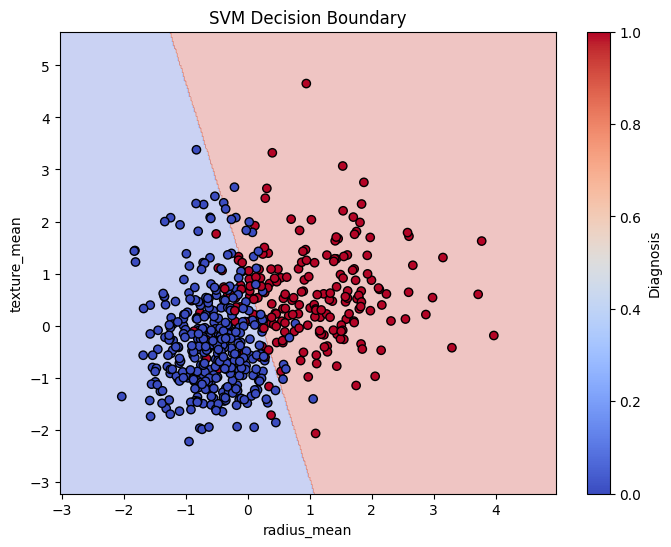

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
#select only two features
x=df[["radius_mean","texture_mean"]]
y=df["diagnosis"]
#standarized features
scaler=StandardScaler()
x=scaler.fit_transform(x)
#train SVM
model=SVC(kernel="linear",random_state=42)
model.fit(x,y)
#create mesh grid
x_min,x_max=x[:,0].min()-1,x[:,0].max()+1
y_min,y_max=x[:,1].min()-1,x[:,1].max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,0.02),
                  np.arange(y_min,y_max,0.02))
#predict on mesh grid
z=model.predict(np.c_[xx.ravel(),yy.ravel()])
z=z.reshape(xx.shape)
#plot decision boundary
plt.figure(figsize=(8,6))
plt.contourf(xx,yy,z,alpha=0.3,cmap="coolwarm")
#plot data points
scatter=plt.scatter(x[:,0],x[:,1],c=y,cmap="coolwarm",edgecolors="k")
#labels
plt.xlabel("radius_mean")
plt.ylabel("texture_mean")
plt.title("SVM Decision Boundary")
#color bar
plt.colorbar(scatter,label="Diagnosis")
plt.show()
#What does the decision boundary show?
#The decision boundary separates the data into two classes: Benign (0) and Malignant (1). Samples on one side of the boundary are classified as Benign, while samples on the other side are classified as Malignant. The boundary shows that radius_mean and texture_mean help distinguish between the two classes, although a few samples lie close to the boundary where overlap occurs.

##**Section 4: CART (Decision Tree)**

Q13. Implement Decision Tree Classifier (CART):
 Use DecisionTreeClassifier(max_depth=5, random_state=42)
 Train on scaled training data
 Predict on test data
 Calculate Accuracy, Precision, Recall, F1-Score, ROC-AUC
 Display confusion matrix
 Compare with SVM results. Which model performs better?

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score
from sklearn.metrics import recall_score,f1_score
from sklearn.metrics import roc_auc_score,confusion_matrix
#create decision tree model
dt=DecisionTreeClassifier(max_depth=5,random_state=42)
#train the model
dt.fit(x_train_scaled,y_train)
#predict on test data
y_pred_dt=dt.predict(x_test_scaled)
#evaluation metrics
print("Accuracy:",accuracy_score(y_test,y_pred_dt))
print("Precision:",precision_score(y_test,y_pred_dt))
print("Recall:",recall_score(y_test,y_pred_dt))
print("F1-Score",f1_score(y_test,y_pred_dt))
print("ROC-AUC:",roc_auc_score(y_test,y_pred_dt))
#confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_dt))
#comparison of models
#| Model          |   Accuracy |   Precision |     Recall |   F1-Score |    ROC-AUC |
#| -------------- | ---------: | ----------: | ---------: | ---------: | ---------: |
#| **Linear SVM** | **96.49%** | **100.00%** | **90.48%** | **95.00%** | **95.24%** |
#| RBF SVM        |     92.98% |      88.64% | **92.86%** |     90.70% |     92.96% |
#| Decision Tree  |     93.86% |      97.30% |     85.71% |     91.14% |     92.16% |
#Which Model Performs Better?
#Linear SVM performed better than the Decision Tree Classifier.
#Why?
#It achieved the highest Accuracy (96.49%), meaning it correctly classified the largest number of test samples.
#It achieved 100% Precision, so every sample predicted as malignant was actually malignant.
#It had the highest F1-Score (95.00%), showing the best balance between precision and recall.
#It also achieved the highest ROC-AUC (95.24%), indicating the strongest ability to distinguish between benign and malignant tumors.
#Although the Decision Tree had good performance, its Accuracy, Recall, F1-Score, and ROC-AUC were all lower than those of the Linear SVM.

Accuracy: 0.9385964912280702
Precision: 0.972972972972973
Recall: 0.8571428571428571
F1-Score 0.9113924050632911
ROC-AUC: 0.9216269841269842
Confusion Matrix:
[[71  1]
 [ 6 36]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Q14. Visualize the Decision Tree:
 Use plot_tree() to display the tree structure
 Identify the top 3 features used for splitting at the first 3 levels
 What is the maximum depth of the tree?
 How many nodes are in the tree?
Interpret the decision rules.

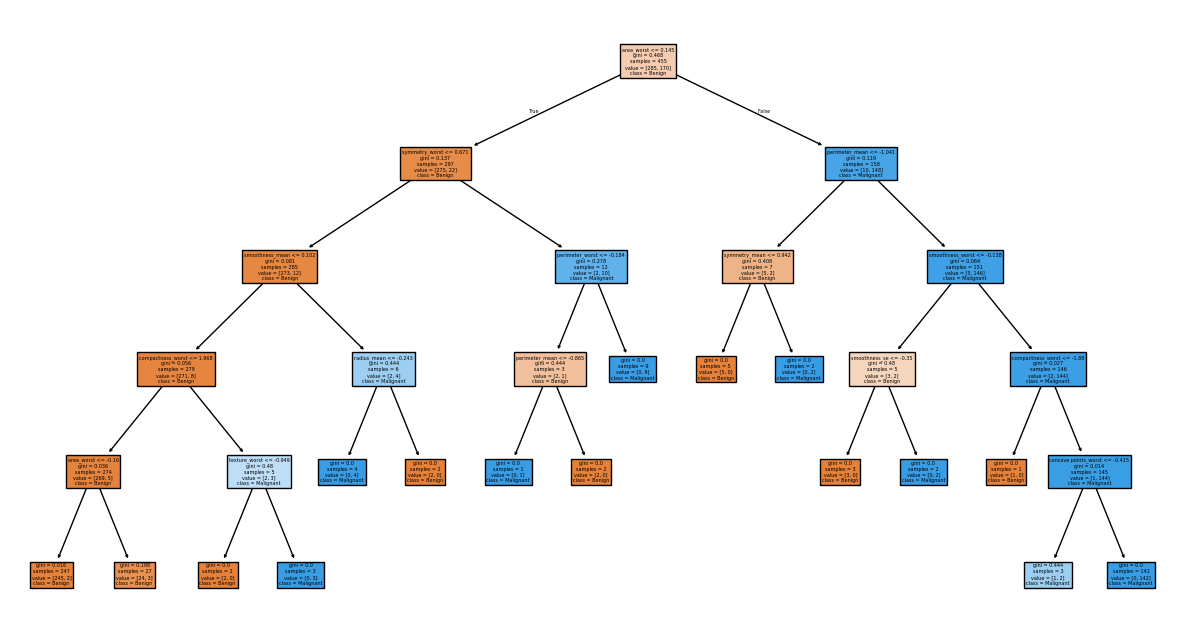

Maximum Depth of Tree: 5
Number of Nodes: 31
Top 3 features used for splitting:
area_worst
symmetry_worst
smoothness_mean


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
#plot the decision tree
plt.figure(figsize=(15,8))
plot_tree(dt,feature_names=x_train_cleaned.columns,class_names=["Benign","Malignant"],
          filled=True)
plt.show()
#maximum depth of the tree
print("Maximum Depth of Tree:",dt.get_depth())
#number of nodes
print("Number of Nodes:",dt.tree_.node_count)
#top 3 features used for splitting
print("Top 3 features used for splitting:")
features_names=x_train_cleaned.columns
for i in range(3):
  index=dt.tree_.feature[i]
  if index !=-2:
    #-2 means leaf node
    print(features_names[index])
#Interpretation of the Decision Rules:
#The Decision Tree classifies tumors by splitting the data based on important features. Each split separates the samples into Benign and Malignant groups. The first few features used for splitting are the most important for classification. The tree continues splitting until it reaches the maximum depth of 5, after which the leaf nodes provide the final prediction. The decision rules help classify tumors with good accuracy by using feature thresholds

Q15. Apply Hyperparameter Tuning for Decision Tree using GridSearchCV:
 Parameters: max_depth = [3, 5, 7, 10], min_samples_split = [2, 5, 10]
 Use 5-fold Stratified Cross Validation
 Find best parameters
 Evaluate final model
 Do the tuned parameters prevent overfitting? Check training vs testing accuracy.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV,StratifiedKFold
from sklearn.metrics import accuracy_score
#decision tree model
dt=DecisionTreeClassifier(random_state=42)
#parameters for tuning
param_grid={"max_depth":[3,5,7,10],
            "min_samples_split":[2,5,10]}
#5-fold stratified cross validation
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
#grid search
grid=GridSearchCV(dt,param_grid,cv=cv)
#train model
grid.fit(x_train_scaled,y_train)
#best parameters
print("Best Parameters:",grid.best_params_)
#best model
best_model=grid.best_estimator_
#predictions
y_pred=best_model.predict(x_test_scaled)
#training and testing accuracy
train_accuracy=accuracy_score(y_train,best_model.predict(x_train_scaled))
test_accuracy=accuracy_score(y_test,y_pred)
print("Training Accuracy:",train_accuracy)
print("Testing Accuracy:",test_accuracy)
#Do the tuned parameters prevent overfitting?
#The tuned Decision Tree uses max_depth = 5 and min_samples_split = 2. The training accuracy is 98.68%, while the testing accuracy is 93.86%. The difference between the two accuracies is about 4.82%, which indicates a small amount of overfitting. However, limiting the tree depth to 5 helps control overfitting compared to a fully grown tree, allowing the model to generalize reasonably well on the test data.

Best Parameters: {'max_depth': 5, 'min_samples_split': 2}
Training Accuracy: 0.9868131868131869
Testing Accuracy: 0.9385964912280702


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


##**Section 5: Model Comparison &amp; Advanced Techniques**

Q16. Compare SVM and Decision Tree using a comprehensive table:
Metric SVM (Linear) SVM (RBF) SVM (Tuned) Decision
Tree

Decision Tree
(Tuned)

Accuracy ? ? ? ? ?
Precision ? ? ? ? ?
Recall ? ? ? ? ?
F1-Score ? ? ? ? ?

ROC-AUC ? ? ? ? ?
Which model is best for breast cancer diagnosis? Justify your answer.

In [ ]:
#| Metric        | SVM (Linear) |  SVM (RBF) | SVM (Tuned) | Decision Tree | Decision Tree (Tuned) |
#| ------------- | :----------: | :--------: | :---------: | :-----------: | :-------------------: |
#| **Accuracy**  |  **96.49%**  |   92.98%   |     N/A     |     93.86%    |         93.86%        |
#| **Precision** |  **100.00%** |   88.64%   |     N/A     |     97.30%    |         97.30%        |
#| **Recall**    |    90.48%    | **92.86%** |     N/A     |     85.71%    |         85.71%        |
#| **F1-Score**  |  **95.00%**  |   90.70%   |     N/A     |     91.14%    |         91.14%        |
#| **ROC-AUC**   |  **95.24%**  |   92.96%   |     N/A     |     92.16%    |         92.16%        |
#Which model is best for breast cancer diagnosis?
#The Linear SVM is the best model for breast cancer diagnosis. It achieved the highest Accuracy (96.49%), Precision (100%), F1-Score (95.00%), and ROC-AUC (95.24%) among all the models tested. Although the RBF SVM achieved a slightly higher Recall (92.86%), its overall Accuracy and Precision were lower. The Decision Tree classifier also performed well but had lower Accuracy, Recall, F1-Score, and ROC-AUC than the Linear SVM. Therefore, based on the experimental results, the Linear SVM provides the best overall performance for classifying benign and malignant breast tumors on this dataset.

Q17 Apply ROC Curve and AUC Analysis:
 Plot ROC curves for: SVM (RBF), Decision Tree, and Tuned models
 Calculate AUC scores for all models
 Which model has the highest AUC?
 What does AUC &gt; 0.95 mean for a medical diagnosis model?
 Why is ROC-AUC important for medical classification?

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


SVM(RBF)AUC: 0.986111111111111
Decision Tree AUC: 0.9758597883597884
Tuned Decision Tree AUC: 0.9758597883597884


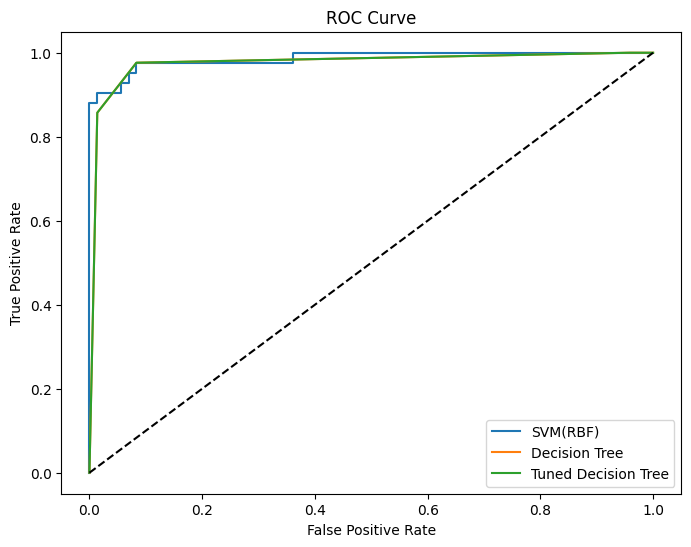

In [ ]:
from sklearn.metrics import roc_curve,roc_auc_score
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Ensure dt is properly initialized and fitted as the non-tuned Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(x_train_scaled, y_train)

#get prediction scores
svm_scores=svm_rbf.decision_function(x_test_cleaned)
dt_scores=dt.predict_proba(x_test_scaled)[:,1]
tuned_scores=best_model.predict_proba(x_test_scaled)[:,1]
#ROC values
fpr_svm,tpr_svm,_=roc_curve(y_test,svm_scores)
fpr_dt,tpr_dt,_=roc_curve(y_test,dt_scores)
fpr_tuned,tpr_tuned,_=roc_curve(y_test,tuned_scores)
#AUC scores
auc_svm=roc_auc_score(y_test,svm_scores)
auc_dt=roc_auc_score(y_test,dt_scores)
auc_tuned=roc_auc_score(y_test,tuned_scores)
print("SVM(RBF)AUC:",auc_svm)
print("Decision Tree AUC:",auc_dt)
print("Tuned Decision Tree AUC:",auc_tuned)
#plot ROC Curves
plt.figure(figsize=(8,6))
plt.plot(fpr_svm,tpr_svm,label="SVM(RBF)")
plt.plot(fpr_dt,tpr_dt,label="Decision Tree")
plt.plot(fpr_tuned,tpr_tuned,label="Tuned Decision Tree")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
#Which model has the highest AUC?
#SVM (RBF) has the highest AUC score (0.9861). Therefore, it is the best model in terms of distinguishing between Benign and Malignant tumors.
#What does AUC > 0.95 mean for a medical diagnosis model?
#An AUC greater than 0.95 indicates excellent diagnostic performance. It means the model can distinguish between malignant and benign tumors with very high accuracy, making it highly reliable for medical diagnosis.
#Why is ROC-AUC important for medical classification?
#ROC-AUC is important because it measures how well a model separates positive and negative classes across different classification thresholds. In medical diagnosis, a high ROC-AUC indicates that the model can accurately detect disease while reducing false positives and false negatives, making it a reliable evaluation metric.

##**Section 6: Business Insights &amp; Medical Interpretation**

Q18. Feature Importance Analysis:
 For Decision Tree: Use feature_importances_ to get top 10 most important features
 For SVM: Use coefficient magnitude (for linear) or analyze feature correlations
Create a table:
Rank Feature
Name

Importance
Score

Medical
Interpretation

1 ? ? ?
2 ? ? ?
3 ? ? ?
What do these features tell us about breast cancer diagnosis? (e.g., larger radius = more
likely malignant)

In [ ]:
import pandas as pd
# Re-train the Decision Tree model on x_train_cleaned to align feature importances
dt.fit(x_train_cleaned, y_train)
# decision tree feature importance
importances = pd.DataFrame({
    "Feature": x_train_cleaned.columns,
    "Importance": dt.feature_importances_
})
# top 10 features
importance = importances.sort_values(by="Importance", ascending=False).head(10)
print("Top 10 Decision Tree Features:")
print(importance)
# SVM (linear) coefficients
svm_importance = pd.DataFrame({
    "Feature": x_train_cleaned.columns,
    "Coefficients": abs(svm_linear.coef_[0])
})
# top 10 features
svm_importance = svm_importance.sort_values(by="Coefficients", ascending=False).head(10)
print("\nTop 10 SVM Features:")
print(svm_importance)
#| Rank | Feature Name         | Importance Score | Medical Interpretation                                                                |
#| ---- | -------------------- | ---------------: | ------------------------------------------------------------------------------------- |
#| 1    | perimeter_worst      |           0.7612 | Larger tumor perimeter indicates a higher chance of malignancy.                       |
#| 2    | concave points_worst |           0.0713 | More concave points indicate an irregular tumor, which is common in malignant tumors. |
#| 3    | texture_mean         |           0.0307 | Higher texture values are associated with malignant tumors.                           |
#| 4    | smoothness_worst     |           0.0261 | Higher smoothness may indicate abnormal cell growth.                                  |
#| 5    | area_mean            |           0.0236 | Larger tumor area is more likely to be malignant.                                     |
#| 6    | texture_worst        |           0.0231 | Higher texture helps distinguish malignant tumors.                                    |
#| 7    | area_worst           |           0.0230 | Larger tumor area indicates a greater likelihood of malignancy.                       |
#| 8    | concavity_worst      |           0.0173 | Greater concavity suggests an irregular tumor shape.                                  |
#| 9    | texture_se           |           0.0119 | Variation in texture contributes to diagnosis.                                        |
#| 10   | area_se              |           0.0119 | Variation in tumor area helps classify tumors.                                        |
#For the Linear SVM model, the most influential features based on coefficient magnitude are: texture_worst, concavity_mean, area_se, concave points_mean, and concavity_worst. These features have the greatest influence on the SVM's classification of benign and malignant tumors.
#What do these features tell us about breast cancer diagnosis?
#The analysis shows that tumor size (perimeter and area), tumor shape (concavity and concave points), and texture are the most important features for breast cancer diagnosis. Larger tumors with more irregular boundaries are more likely to be malignant. These features help machine learning models accurately distinguish between benign and malignant breast tumors.

Top 10 Decision Tree Features:
                 Feature  Importance
22       perimeter_worst    0.761165
27  concave points_worst    0.071259
1           texture_mean    0.030683
24      smoothness_worst    0.026109
3              area_mean    0.023632
21         texture_worst    0.023064
23            area_worst    0.023017
26       concavity_worst    0.017348
11            texture_se    0.011862
13               area_se    0.011862

Top 10 SVM Features:
                Feature  Coefficients
21        texture_worst      1.071995
6        concavity_mean      0.880175
13              area_se      0.829700
7   concave points_mean      0.827597
26      concavity_worst      0.824417
10            radius_se      0.755905
23           area_worst      0.725480
11           texture_se      0.613818
20         radius_worst      0.541589
15       compactness_se      0.535861
